# Feedforward Neural Networks

We look at the basics of building neural networks in pytorch, and see how we can use them for computations.

We do not yet get into training.

In [ ]:
# import the PyTorch library -- open-source machine learning library
# for building and training deep learning models.
# used for tasks in computer vision, natural language processing, etc.

import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
# Define the neural network
class VerySimpleNet(nn.Module): #the class inherits from the nn.Module
    def __init__(self): # initialize the network layers.
        super(VerySimpleNet, self).__init__() #calls the parent class's constructor to properly initialize the nn.Module.
        self.fc1 = nn.Linear(3, 1)  # a fully connected (linear) layer with 3 inputs and 1 output

    def forward(self, x): # defines how the data passes through the network.
        x = self.fc1(x) # it is passed through self.fc1
        return x



In [ ]:
mymodel = VerySimpleNet()


In [ ]:
mymodel

VerySimpleNet(
  (fc1): Linear(in_features=3, out_features=1, bias=True)
)

In [ ]:
mymodel.fc1.bias

Parameter containing:
tensor([-0.4557], requires_grad=True)

In [ ]:
# Define the neural network
class LessSimpleNet(nn.Module):
    def __init__(self):
        super(LessSimpleNet, self).__init__() #calls the parent class's constructor to properly initialize the nn.Module.
        self.fc1 = nn.Linear(4, 3)  # a fully connected (linear) layer with 3 inputs and 1 output
        self.fc2 = nn.Linear(3, 1)  # a fully connected (linear) layer with 3 inputs and 1 output

    def forward(self, x): #defines how the data passes through the network.
        x = self.fc1(x) #it is passed through self.fc1
        x = self.fc2(x) #it is passed through self.fc2
        return x


### We initialize the model

We do this using the same commands that we were using for sklearn.

In [ ]:
mymodel1 = VerySimpleNet()
mymodel1

VerySimpleNet(
  (fc1): Linear(in_features=3, out_features=1, bias=True)
)

In [ ]:
mymodel2 = LessSimpleNet()
mymodel2

LessSimpleNet(
  (fc1): Linear(in_features=4, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=1, bias=True)
)

In [ ]:
mymodel2

LessSimpleNet(
  (fc1): Linear(in_features=4, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=1, bias=True)
)

### Specific layers

We can access specific layers if we know their name.
This will be very important when we get to transfer learning, and start using much larger networks.


In [ ]:
mymodel2

LessSimpleNet(
  (fc1): Linear(in_features=4, out_features=3, bias=True)
  (fc2): Linear(in_features=3, out_features=1, bias=True)
)

In [ ]:
mymodel2.fc1.weight

Parameter containing:
tensor([[-0.4938,  0.4516, -0.4247,  0.3860],
        [ 0.0832, -0.1624,  0.3090,  0.0779],
        [ 0.4040,  0.0547, -0.1577,  0.1343]], requires_grad=True)

In [ ]:
mymodel1

VerySimpleNet(
  (fc1): Linear(in_features=3, out_features=1, bias=True)
)

In [ ]:
mymodel1.fc1.weight

Parameter containing:
tensor([[-0.2662, -0.1630, -0.3471]], requires_grad=True)

### Set specific weights

We can set values for the weights and biases, again by using the specific names of the layers.

$$
\alpha_1 = 1
$$
$$
\alpha_2 = 1
$$
$$
\alpha 3 = 2
$$
$$
\beta = 2
$$


In [ ]:
# this is going to give me an error
# I need to use torch tensors
# mymodel1.fc1 = [1,1,2]

In [ ]:
# Manually set weights and biases for the network
mymodel1.fc1.weight = nn.Parameter(torch.tensor([[1., 1., 2.]])) # vals for α1, α2, α3
mymodel1.fc1.bias = nn.Parameter(torch.tensor([2.])) #  β


In [ ]:
mymodel1.fc1.weight

Parameter containing:
tensor([[1., 1., 2.]], requires_grad=True)

### Input / Output

Let's see how the computation goes

In [ ]:
# Create a small dataset of integer inputs
# note that they need to be ``torch.tensor``.

inputs = torch.tensor([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]], dtype=torch.float32)

# Feed inputs to the network and print outputs
outputs = mymodel1(inputs)
print(outputs)

tensor([[11.],
        [23.],
        [35.]], grad_fn=<AddmmBackward0>)


### Two layers

In [ ]:
# Define the neural network
class SimpleNet(nn.Module):
    def __init__(self):
        super(SimpleNet, self).__init__()
        self.fc1 = nn.Linear(3, 2)  # 3 inputs to 2 outputs
        self.fc2 = nn.Linear(2, 1)  # 2 inputs to 1 output
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x



In [ ]:
# Create an instance of the network
model = SimpleNet()

In [ ]:
# Manually set weights and biases for the network
# as we did before
model.fc1.weight = nn.Parameter(torch.tensor([[1., 0., 3.], [-1., 2., 1.]])) # α, β, ...
model.fc1.bias = nn.Parameter(torch.tensor([0., 1.])) # c1, c2
model.fc2.weight = nn.Parameter(torch.tensor([[1., 2.]])) # μ, ν
model.fc2.bias = nn.Parameter(torch.tensor([1.])) # c3

In [ ]:
model

SimpleNet(
  (fc1): Linear(in_features=3, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
)

### Let's see what it does

In [ ]:
# Create a small dataset of integer inputs
inputs = torch.tensor([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]], dtype=torch.float32)

# Feed inputs to the network and print outputs
outputs = model(inputs)
print(outputs)


tensor([[25.],
        [49.],
        [73.]], grad_fn=<AddmmBackward0>)


In [ ]:
model.fc2 = nn.Linear(2,2)

In [ ]:
model

SimpleNet(
  (fc1): Linear(in_features=3, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=2, bias=True)
  (relu): ReLU()
)

In [ ]:
model(inputs)

tensor([[ -4.9560,  -3.0834],
        [-10.7177,  -7.5667],
        [-16.4795, -12.0500]], grad_fn=<AddmmBackward0>)

# XOR_NNet()

We saw this dataset in the lecture, and also I gave values of the weights and biases for which this 2 layer non-linear network matches XOR.

In [ ]:
# Define the neural network
class XOR_NNet(nn.Module):
    def __init__(self):
        super(XOR_NNet, self).__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

### Random initialization

Every time we give the mode
```
mymodel = NNet()
```
the weights are randomly initialized.
It is useful, therefore, to fix the random seed.

In [ ]:
# set the torch seed
torch.manual_seed(42)
mymodel = XOR_NNet()

### Pick Weights

In [ ]:
# Uncomment and manually set weights and biases for the network

#model.fc1.weight = nn.Parameter(torch.tensor([[α, β], [γ, δ]]))
#model.fc1.bias = nn.Parameter(torch.tensor([c1, c2]))
#model.fc2.weight = nn.Parameter(torch.tensor([[μ, ν]]))
#model.fc2.bias = nn.Parameter(torch.tensor([c3]))

In [ ]:
# Make inputs
inputs = torch.tensor([[0,0],
                       [0,1],
                       [1,0],
                       [1,1]], dtype=torch.float32)


### Check...

In [ ]:
# Feed inputs to the network and print outputs
outputs = mymodel(inputs)
print(outputs)

tensor([[0.6826],
        [0.8036],
        [0.4906],
        [0.5487]], grad_fn=<AddmmBackward0>)


In [ ]:
mymodel

XOR_NNet(
  (fc1): Linear(in_features=2, out_features=2, bias=True)
  (fc2): Linear(in_features=2, out_features=1, bias=True)
  (relu): ReLU()
)

# Classification

Now let's move to neural nets for classification. We will need as many outputs as we have classes (all the networks above have just one single output -- this would be appropriate for regression problems).

### Softmax

Recall the definition of Softmax:

$$
p_1 = \frac{exp(z_1)}{(exp(z_1) + exp(z_2) + \cdots +exp(z_{10})}
$$


$$
p_2 = \frac{exp(z_2)}{(exp(z_1) + exp(z_2) + \cdots +exp(z_{10})}
$$

$$
\vdots
$$

$$
p_{10} = \frac{exp(z_{10})}{(exp(z_1) + exp(z_2) + \cdots +exp(z_{10})}
$$



### Let's make some data

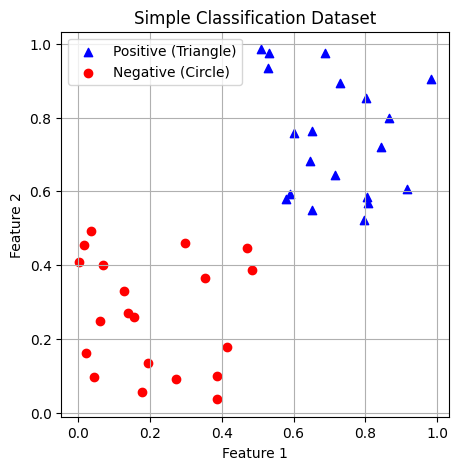

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples in the upper right quadrant
X_positive = np.random.uniform(0.5,1.0,(20,2))

# Generate negative examples in the lower left quadrant
X_negative = np.random.uniform(0.0, 0.5,(20,2))

# Plotting the data
plt.figure(figsize=(5, 5))
plt.scatter(X_positive[:,0],X_positive[:,1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(X_negative[:,0],X_negative[:,1], marker='o', color='red', label='Negative (Circle)')
plt.title('Simple Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


### Define neural net for classification

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleClassifier(nn.Module):
    def __init__(self):
        super(SimpleClassifier, self).__init__()
        self.fc = nn.Linear(2, 2)  # Input dimension is 2, output dimension is 2 (one for each class)

    def forward(self, x):
        x = self.fc(x)
        return x # these are the logits --


### This is just logistic regression

On input (x1,x2)

usual logistic regression:
z = b0 + b1 x1 + b2 x2

to get probabilities, we used sigmoid function
prob of 1 = exp(z) / (1 + exp(z))
prob of 0 = 1 - prob 1

now what we are implementing looks a little different, but is actually completely equivalent:

z1 = b01 + b11x1 + b12 x2
z2 = b02 + b21x1 + b22 x2

to get probabilities we use softmax:

prob of 1 = exp(z1)/(exp(z1) + exp(z2))
prob of 0 = exp(z2)/(exp(z1) + exp(z2))


### Set weights

We're not yet using gradient descent. Let's manually set the weights.

In [ ]:
model = SimpleClassifier()

# Set weights and biases
model.fc.weight = nn.Parameter(torch.tensor([[1.0, 1.0], [-1.0, -1.0]]))
model.fc.bias = nn.Parameter(torch.tensor([-1.0, 1.0]))


In [ ]:
model

SimpleClassifier(
  (fc): Linear(in_features=2, out_features=2, bias=True)
)

In [ ]:
# Select a few examples
points = torch.tensor([[0.1, 0.15],[0.8,0.8],[0.5,0.45]], dtype=torch.float32)

# Feed them through the network
outputs = model(points)

print("Outputs for selected points:\n", outputs)


Outputs for selected points:
 tensor([[-0.7500,  0.7500],
        [ 0.6000, -0.6000],
        [-0.0500,  0.0500]], grad_fn=<AddmmBackward0>)


### Is our network any good?

Based on the outputs above, is our network any good for the specific dataset?

### Contours and level sets

As we did for logistic regression (note... we are basically just implementing logistic regression in pytorch!) we can plot the contours of our classifier to visualize what it is doing.

In [ ]:
# Function to plot decision boundaries
def plot_decision_boundary(model, X, y):

    # make a fine mesh grid of points and label them with model
    x_min, x_max = X[:,0].min(), X[:,0].max()
    y_min, y_max = X[:,1].min(), X[:,1].max()
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    with torch.no_grad():
        probs = model(grid)
        Z = probs[:, 0] - probs[:, 1]
        Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, cmap="RdBu", alpha=0.5)

    # Now plot the original points, along with their true label given in y
    # Extract positive and negative indices based on y
    positive_indices = np.where(y == 1)[0]
    negative_indices = np.where(y == 0)[0]

    # Split X into positive and negative components
    X_positive = X[positive_indices, :]
    X_negative = X[negative_indices, :]
    plt.scatter(X_positive[:,0], X_positive[:,1], marker='^', color='blue', label='Positive (Triangle)')
    plt.scatter(X_negative[:,0], X_negative[:,1], marker='o', color='red', label='Negative (Circle)')
    plt.title("Decision Region with Data Points")
    plt.show()




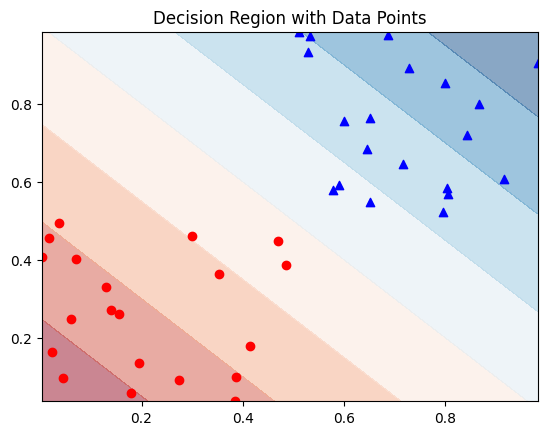

In [ ]:
X = np.vstack((X_positive,X_negative))
y = np.array([1]*20 + [0]*20)  # Correctly assigning labels to each class

plot_decision_boundary(model, X, y)

### Linear level sets

The level sets are... linear! Is this a surprise? Can you predict what would happen if add more layers?

## A Second Example

Let's create an example where we want non-linear level sets.

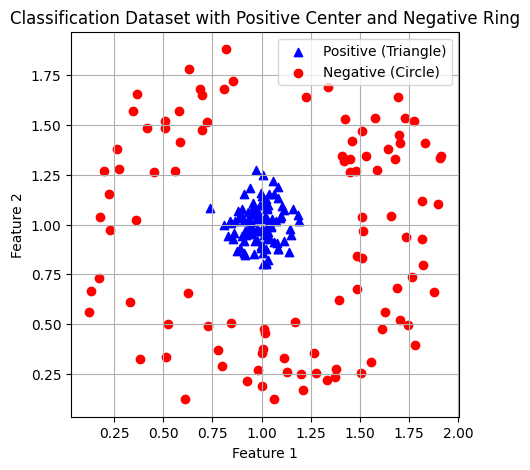

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Seed for reproducibility
np.random.seed(42)

# Generate positive examples centered around (1,1)
positive_x = 0.1 * np.random.randn(100, 2) + 1

# Generate negative examples in a ring-like structure
radius = 0.5 + 0.5 * np.random.rand(100, 1)
angle = 2 * np.pi * np.random.rand(100, 1)
negative_x = np.hstack((radius * np.cos(angle), radius * np.sin(angle))) + 1

# Plotting the data
plt.figure(figsize=(5, 5))
plt.scatter(positive_x[:, 0], positive_x[:, 1], marker='^', color='blue', label='Positive (Triangle)')
plt.scatter(negative_x[:, 0], negative_x[:, 1], marker='o', color='red', label='Negative (Circle)')
plt.title('Classification Dataset with Positive Center and Negative Ring')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


### What will we need here?

We saw this example once before when we talked about feature generation in logistic regression. There, we came up with a **custom** solution using feature engineering.

Once we learn how to train, we will see that neural networks allow us to obtain a solution in a more automatic way, where rather than manually defining feature generation, **we have neural networks search over good feature generation approaches** before training the final logistic regression-like layer.

## Additional Methods

We have a self.forward() method.

We will now add ``self.predict()`` and ``self.predict_proba()`` methods and see how they work.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimplePlusPlusClassifier(nn.Module):
    def __init__(self):
        super(SimplePlusPlusClassifier, self).__init__()
        self.fc = nn.Linear(2, 2)  # Input dimension is 2, output dimension is 2 (one for each class)

    def forward(self, x):
        x = self.fc(x)
        return x # note -- returning logits

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = F.softmax(logits, dim=1)
        return probs.detach().cpu().numpy()

    def predict(self, x):
        logits = self.forward(x)
        prediction = torch.argmax(logits, dim=1)
        return prediction.detach().cpu().numpy()


In [ ]:
model = SimplePlusPlusClassifier()

# Set weights and biases
model.fc.weight = nn.Parameter(torch.tensor([[1.0, 1.0], [-1.0, -1.0]]))
model.fc.bias = nn.Parameter(torch.tensor([-1.0, 1.0]))


In [ ]:
# example from above
inputs = torch.tensor([[0.1, 0.15],[0.8,0.8],[0.5,0.45]], dtype=torch.float32)
inputs

tensor([[0.1000, 0.1500],
        [0.8000, 0.8000],
        [0.5000, 0.4500]])

In [ ]:
model(inputs)

tensor([[-0.7500,  0.7500],
        [ 0.6000, -0.6000],
        [-0.0500,  0.0500]], grad_fn=<AddmmBackward0>)

In [ ]:
model.predict_proba(inputs)

array([[0.18242551, 0.81757444],
       [0.7685248 , 0.23147522],
       [0.47502077, 0.5249792 ]], dtype=float32)

In [ ]:
model.predict(inputs)


array([1, 0, 1])